In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
print("Βιβλιοθήκες φορτώθηκαν. Έτοιμοι για την προεπεξεργασία των 5G δεδομένων.")

In [ ]:
# Φόρτωση
train_df = pd.read_csv('/Users/antonistsipoulakos/Downloads/UNSW_NB15_training-set(in).csv')
test_df = pd.read_csv('/Users/antonistsipoulakos/Downloads/UNSW_NB15_testing-set(in).csv')

print(f" Αρχικό μέγεθος Train: {train_df.shape}")

# Καθαρισμός βάσει λογικής (Βήμα 2 εκφώνησης)
# Διαγράφουμε το 'id' (αύξων αριθμός) και το 'attack_cat' (λεπτομέρειες επίθεσης) 
# γιατί κάνουμε Δυαδική Κατηγοριοποίηση (Normal vs Attack).
train_df = train_df.drop(['id', 'attack_cat'], axis=1)
test_df = test_df.drop(['id', 'attack_cat'], axis=1)

X_train = train_df.drop('label', axis=1)
y_train = train_df['label']
X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

print(" Διαγράφηκαν οι στήλες 'id' και 'attack_cat' ως μη σχετικές με τη δυαδική πρόβλεψη.")
print(f" Διαχωρισμός ολοκληρώθηκε. Στόχος (Label): 0 = Normal, 1 = Attack.")

Τα δεδομένα φορτώθηκαν και καθαρίστηκαν!


In [ ]:
print(" Μετατροπή ποιοτικών χαρακτηριστικών (proto, service, state) σε Dummy variables...")
categorical_cols = ['proto', 'service', 'state']
X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)

# Ευθυγράμμιση: Αν το Test έχει λιγότερα πρωτόκολλα από το Train, γεμίζουμε με 0.
X_test = X_test.reindex(columns=X_train.columns, fill_value=0) 

print(f" Μετά τα Dummies, οι στήλες αυξήθηκαν σε: {X_train.shape[1]}")

print(" Εφαρμογή Min-Max Scaling στο διάστημα [0, 1]...")
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f" Η κανονικοποίηση ολοκληρώθηκε. Ελάχιστο: {X_train.min().min()}, Μέγιστο: {X_train.max().max()}")

✅ Η προεπεξεργασία (Dummies & Scaling) ολοκληρώθηκε!


In [ ]:
def objective(trial):
    # Παράμετροι που ζητάει η εκφώνηση (eta/learning_rate, gamma, max_depth)
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'random_state': 42
    }
    
    model = xgb.XGBClassifier(**param)
    
    # 10-fold Cross Validation (Απαίτηση εκφώνησης)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    
    return np.mean(scores)

print(" Έναρξη βελτιστοποίησης υπερπαραμέτρων (Optuna Tuning)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) # Μπορείς να το κάνεις 20 ή 30 για την τελική αναφορά

print("\n Tuning Ολοκληρώθηκε!")
print(f"Καλύτερες Παράμετροι: {study.best_params}")
print(f"Καλύτερη Ακρίβεια στο Train (CV Score): {study.best_value:.4f}")

# Εκπαίδευση τελικού μοντέλου
print(" Εκπαίδευση τελικού XGBoost με τις βέλτιστες παραμέτρους...")
final_xgb_model = xgb.XGBClassifier(**{**study.best_params, 'objective': 'binary:logistic', 'eval_metric': 'logloss'})
final_xgb_model.fit(X_train, y_train)
print(" Το μοντέλο εκπαιδεύτηκε και είναι έτοιμο για αξιολόγηση.")

[I 2026-03-24 18:51:07,169] A new study created in memory with name: no-name-588c7569-2bd7-41e7-b1ca-4794618dab52


⏳ Ξεκινάει το Tuning με την Optuna...


[I 2026-03-24 18:51:17,677] Trial 0 finished with value: 0.9556692373860045 and parameters: {'learning_rate': 0.0809098917742936, 'max_depth': 6, 'gamma': 0.030345280110865458, 'n_estimators': 171}. Best is trial 0 with value: 0.9556692373860045.
[I 2026-03-24 18:51:26,419] Trial 1 finished with value: 0.9563479165282335 and parameters: {'learning_rate': 0.14600808152642403, 'max_depth': 5, 'gamma': 0.1693132030407699, 'n_estimators': 177}. Best is trial 1 with value: 0.9563479165282335.
[I 2026-03-24 18:51:32,677] Trial 2 finished with value: 0.9441602255574562 and parameters: {'learning_rate': 0.057253624818233886, 'max_depth': 5, 'gamma': 0.7542378883372846, 'n_estimators': 83}. Best is trial 1 with value: 0.9563479165282335.
[I 2026-03-24 18:51:40,889] Trial 3 finished with value: 0.9354001651408845 and parameters: {'learning_rate': 0.019924150560278544, 'max_depth': 4, 'gamma': 0.7291150995742294, 'n_estimators': 155}. Best is trial 1 with value: 0.9563479165282335.
[I 2026-03-24 

Το XGBoost είναι έτοιμο!


📊 ΑΠΟΤΕΛΕΣΜΑΤΑ XGBoost:
------------------------------
✅ Accuracy: 87.49%
✅ Precision: 0.8232
✅ Recall: 0.9842
✅ F1-Score: 0.8965
✅ ROC AUC: 0.9837



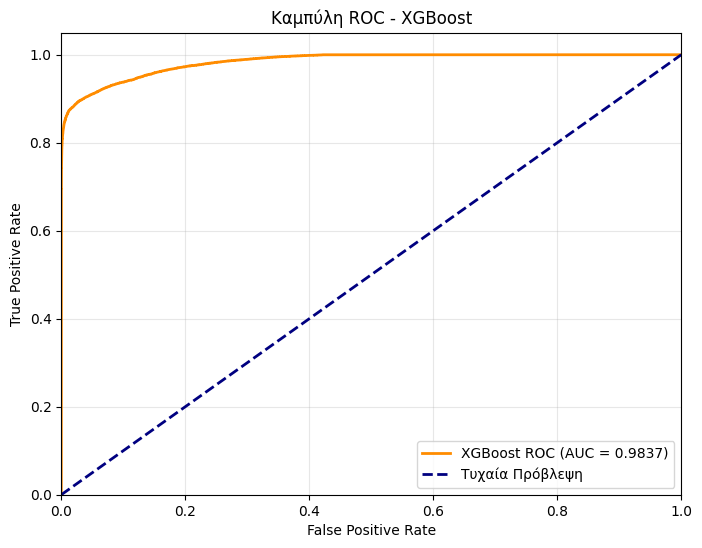

In [ ]:
print(" Αξιολόγηση μοντέλου στο Test Set (Αόρατα δεδομένα)...")
y_pred = final_xgb_model.predict(X_test)
y_proba = final_xgb_model.predict_proba(X_test)[:, 1] 

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\n" + "="*40)
print("       ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ XGBOOST")
print("="*40)
print(f" Accuracy:  {acc*100:.2f}% (Συνολική ορθότητα)")
print(f" Precision: {prec:.4f} (Πόσο έγκυρος είναι ο συναγερμός επίθεσης)")
print(f" Recall:    {rec:.4f} (Πόσες από τις πραγματικές επιθέσεις βρήκαμε)")
print(f"  F1-Score:  {f1:.4f} (Ισορροπία Precision/Recall)")
print(f"  ROC AUC:   {roc_auc:.4f} (Ικανότητα διαχωρισμού normal/attack)")
print("="*40)

# Γράφημα
print("\n Δημιουργία καμπύλης ROC...")
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Λάθος Συναγερμοί)')
plt.ylabel('True Positive Rate (Σωστές Ανιχνεύσεις)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()